In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

In [1]:
import h5py
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from pathlib import Path
from tqdm import tqdm
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler

# =================配置区域=================
N_BEST_VOXELS = 500   # 核心：只保留每人最强的500个体素
DATA_DIR = Path("data/ToM_Data/Human_fMRI_Data")
ROI_FILE = "Left_TPJ.h5"  # 继续使用效果最好的左侧TPJ
PERIOD = "Belief_Period_H5" 
SUBJECTS = [f"TOM{i:03d}" for i in range(1, 22) if i != 6]
BATCH_SIZE = 32      # VAE训练常用的Batch Size

# =================核心处理函数=================
def prepare_vae_dataset(data_dir, roi_file, n_voxels):
    print(f"--- 开始构建 VAE 数据集 ---")
    print(f"策略: HRF Shift (后2TR平均) -> ANOVA SelectKBest ({n_voxels}) -> StandardScaler")
    
    all_X = []
    all_y = []      # 虽然VAE是无监督的，但保留标签用于后续评估或CVAE
    all_subjects = [] # 保留被试ID，方便做Leave-One-Out
    
    for sub_idx, sub in enumerate(tqdm(SUBJECTS)):
        input_file = data_dir / PERIOD / sub / roi_file
        
        sub_X = []
        sub_y = []
        
        try:
            with h5py.File(input_file, 'r') as f:
                for cond_name in f.keys():
                    for trial_name in f[cond_name].keys():
                        group = f[cond_name][trial_name]
                        signal = group['Signal'][()] 
                        label = int(group['Condition_Number'][()])
                        
                        # [关键步骤 1] HRF 矫正：只取最后2个TR并平均
                        if signal.shape[0] >= 4:
                            valid_signal = signal[-2:, :] 
                            trial_vec = np.mean(valid_signal, axis=0)
                            trial_vec = np.nan_to_num(trial_vec)
                            
                            sub_X.append(trial_vec)
                            sub_y.append(label)
        except Exception as e:
            print(f"Error reading {sub}: {e}")
            continue
        
        if len(sub_X) == 0: continue
            
        # 转为 numpy
        sub_X = np.array(sub_X)
        sub_y = np.array(sub_y)
        
        # [关键步骤 2] 特征选择 (SelectKBest)
        # 在被试内部，选出对任务最敏感的 500 个体素
        if sub_X.shape[1] > n_voxels:
            selector = SelectKBest(f_classif, k=n_voxels)
            sub_X_selected = selector.fit_transform(sub_X, sub_y)
        else:
            # 如果体素本身就不够500个(比如Mask很小)，就全保留，并补0 (可选，这里暂不补0)
            print(f"Warning: Subject {sub} has fewer than {n_voxels} voxels.")
            sub_X_selected = sub_X
            
        # [关键步骤 3] 标准化 (Z-score)
        # 对神经网络训练至关重要
        scaler = StandardScaler()
        sub_X_norm = scaler.fit_transform(sub_X_selected)
        
        all_X.append(sub_X_norm)
        all_y.append(sub_y)
        all_subjects.append(np.full(len(sub_y), sub_idx)) # 记录被试编号

    # 拼接所有被试的数据
    X_final = np.vstack(all_X).astype(np.float32)
    y_final = np.concatenate(all_y).astype(np.int64)
    sub_final = np.concatenate(all_subjects).astype(np.int64)
    
    print(f"\n数据集准备完毕!")
    print(f"输入形状 (X): {X_final.shape}  (Samples, Features)")
    print(f"标签形状 (y): {y_final.shape}")
    
    # 转换为 PyTorch Tensor
    tensor_x = torch.from_numpy(X_final)
    tensor_y = torch.from_numpy(y_final)
    tensor_sub = torch.from_numpy(sub_final)
    
    # 创建 Dataset
    # 包含: 输入数据, 条件标签, 被试ID
    dataset = TensorDataset(tensor_x, tensor_y, tensor_sub)
    
    return dataset, X_final.shape[1]

# =================执行=================
# 1. 生成 Dataset
vae_dataset, input_dim = prepare_vae_dataset(DATA_DIR, ROI_FILE, N_BEST_VOXELS)

# 2. 创建 DataLoader (供VAE训练使用)
# shuffle=True 打乱数据，有助于训练
train_loader = DataLoader(vae_dataset, batch_size=BATCH_SIZE, shuffle=True)

# 3. (可选) 创建一个不打乱的 Loader 用于测试/可视化
test_loader = DataLoader(vae_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\n--- Ready for VAE ---")
print(f"Input Dimension for VAE: {input_dim}")
print(f"Total Batches: {len(train_loader)}")

--- 开始构建 VAE 数据集 ---
策略: HRF Shift (后2TR平均) -> ANOVA SelectKBest (500) -> StandardScaler


 70%|███████   | 14/20 [00:00<00:00, 68.87it/s]/home/yingziyu/.conda/envs/ToM-Net/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [2142] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/yingziyu/.conda/envs/ToM-Net/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
100%|██████████| 20/20 [00:00<00:00, 69.02it/s]


数据集准备完毕!
输入形状 (X): (1280, 500)  (Samples, Features)
标签形状 (y): (1280,)

--- Ready for VAE ---
Input Dimension for VAE: 500
Total Batches: 40


In [7]:
class VAE(nn.Module):
    def __init__(self, input_dim, batch_dim, latent_dim):
        super(VAE, self).__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.fc2 = nn.Linear(256 + batch_dim, 256)
        self.fc21 = nn.Linear(256, latent_dim)  # 均值
        self.fc22 = nn.Linear(256, latent_dim)  # 对数方差
        self.fc3 = nn.Linear(latent_dim + batch_dim, 256)
        self.fc4 = nn.Linear(256, input_dim)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
    def encode(self, x, batch_info):
        h1 = self.relu(self.fc1(x))
        h2 = self.relu(self.fc2(torch.cat([h1, batch_info], dim=1)))
        return self.fc21(h2), self.fc22(h2)
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    def decode(self, z, batch_info):
        h3 = self.relu(self.fc3(torch.cat([z, batch_info], dim=1)))
        return self.fc4(h3)
    def forward(self, x, batch_info):
        mu, logvar = self.encode(x, batch_info)
        z = self.reparameterize(mu, logvar)
        return self.decode(z, batch_info), mu, logvar

model = VAE(input_dim=input_dim, batch_dim=20, latent_dim=20).to(torch.device('cuda' if torch.cuda.is_available() else 'cpu'))

In [ ]:
epochs = 100
loss_fn = nn.MSELoss(reduction='sum')
def loss_function(recon_x, x, mu, logvar, beta=1.0):
    # 注意：这里变量名虽叫BCE，但你是用MSELoss，对于fMRI连续值是对的
    Recon_Loss = loss_fn(recon_x, x) 
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return Recon_Loss + beta * KLD

optimizer = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(epochs):
    for x, y, sub_id in train_loader:
        # x: (32, 500) -> 你的输入
        # y: (32,)     -> 8个条件标签 (如果你想做 CVAE，就把这个拼进去)
        # sub_id: (32,) -> 被试ID (如果你想处理批次效应，可以用这个)
        batch_info = torch.nn.functional.one_hot(sub_id, num_classes=20).float()
        batch_info = batch_info.to(torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
        x = x.to(torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
        recon_x, mu, logvar = model(x, batch_info)
        loss = loss_function(recon_x, x, mu, logvar)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item()/len(x):.4f}")


Epoch 1, Loss: 506.8394
Epoch 2, Loss: 473.3292
Epoch 3, Loss: 495.1331
Epoch 4, Loss: 462.7289
Epoch 5, Loss: 465.8199
Epoch 6, Loss: 436.9066
Epoch 7, Loss: 419.5023
Epoch 8, Loss: 430.7704
Epoch 9, Loss: 396.3934
Epoch 10, Loss: 394.8226
Epoch 11, Loss: 390.9145
Epoch 12, Loss: 400.5316
Epoch 13, Loss: 374.7806
Epoch 14, Loss: 379.9668
Epoch 15, Loss: 409.3549
Epoch 16, Loss: 398.7418
Epoch 17, Loss: 398.7384
Epoch 18, Loss: 364.2709
Epoch 19, Loss: 387.2921
Epoch 20, Loss: 366.6526
Epoch 21, Loss: 359.4909
Epoch 22, Loss: 360.2012
Epoch 23, Loss: 346.6978
Epoch 24, Loss: 353.7551
Epoch 25, Loss: 341.1079
Epoch 26, Loss: 363.3760
Epoch 27, Loss: 341.2422
Epoch 28, Loss: 342.0715
Epoch 29, Loss: 329.8121
Epoch 30, Loss: 343.7237
Epoch 31, Loss: 333.3135
Epoch 32, Loss: 360.2501
Epoch 33, Loss: 319.1771
Epoch 34, Loss: 323.1793
Epoch 35, Loss: 346.9050
Epoch 36, Loss: 334.0501
Epoch 37, Loss: 290.8717
Epoch 38, Loss: 320.7226
Epoch 39, Loss: 322.8936
Epoch 40, Loss: 317.6663
Epoch 41,

/home/yingziyu/.conda/envs/ToM-Net/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/yingziyu/.conda/envs/ToM-Net/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


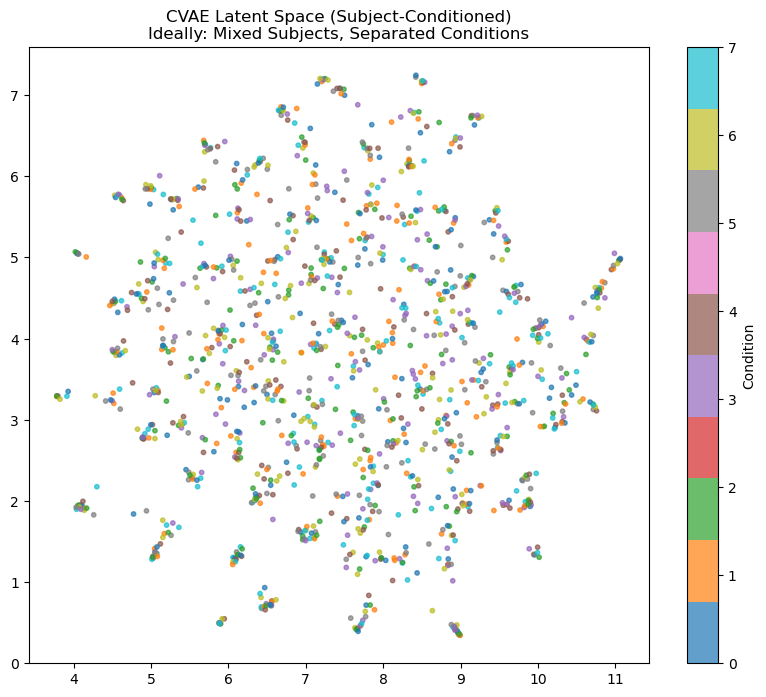

In [10]:
# --- 训练结束后 ---
model.eval() # 切换到评估模式
all_latents = []
all_labels = []
all_subs = []
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

with torch.no_grad():
    for x, y, sub_id in train_loader: # 或者 test_loader
        x = x.to(device)
        # 构造 condition
        batch_info = torch.nn.functional.one_hot(sub_id, num_classes=20).float().to(device)
        
        # 只拿 mu (这是降维后的特征)
        # 注意：你的 model.forward 最好能支持只输出 mu，或者在这里手动调用 encoder
        # 假设 model 返回 (recon_x, mu, logvar)
        _, mu, _ = model(x, batch_info)
        
        all_latents.append(mu.cpu().numpy())
        all_labels.append(y.numpy())
        all_subs.append(sub_id.numpy())

# 拼接结果
X_vae = np.vstack(all_latents)
y_vae = np.concatenate(all_labels)
sub_vae = np.concatenate(all_subs)

# --- 此时可以用 X_vae 做 UMAP 或 RSA 了 ---
import umap
import matplotlib.pyplot as plt

reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X_vae)

plt.figure(figsize=(10, 8))
# 颜色用 Condition (任务)，形状用 Subject (被试 - 可选)
plt.scatter(embedding[:, 0], embedding[:, 1], c=y_vae, cmap='tab10', s=10, alpha=0.7)
plt.title(f"CVAE Latent Space (Subject-Conditioned)\nIdeally: Mixed Subjects, Separated Conditions")
plt.colorbar(label='Condition')
plt.show()